# 03 — Sequence Data

Sequence data is data where the **order of observations matters**.

Unlike ordinary tabular data, observations in a sequence are usually not independent of one another. The current observation may depend on previous observations, and sometimes future observations are also relevant.

Examples include:

- Time-series data
- Stock prices
- Weather measurements
- Sensor signals
- Speech
- Text
- DNA sequences
- User activity
- Machine logs
- Transaction sequences
- Medical monitoring data

The main goal of sequence modeling is to learn the relationship between observations while preserving their ordering and temporal or sequential dependencies.

## 1. What Is Sequence Data?

A sequence can be represented as:

$$
X = (x_1, x_2, x_3, \ldots, x_T)
$$

where:

- $x_t$ = observation at position or time $t$
- $T$ = sequence length
- $X$ = complete sequence

For a multivariate sequence:

$$
x_t \in \mathbb{R}^d
$$

where $d$ is the number of features observed at each time step.

Therefore:

$$
X \in \mathbb{R}^{T \times d}
$$

A sequence is fundamentally different from an unordered collection because:

$$
(x_1,x_2,x_3) \neq (x_3,x_2,x_1)
$$

in general.

The ordering contains information.

## 2. Why Is Sequence Data Different?

Traditional machine learning often assumes that observations are independent and identically distributed (i.i.d.):

$$
P(X_1,\ldots,X_n)
=
\prod_{i=1}^{n}P(X_i)
$$

For sequential data, this assumption may not hold.

Instead, observations can depend on previous observations:

$$
P(x_t \mid x_{t-1},x_{t-2},\ldots)
$$

This dependency structure is what makes sequence modeling different from ordinary supervised learning.

### Key characteristics

1. **Ordering matters**
2. **Observations may be dependent**
3. **Past information can influence the future**
4. **Sequences may have variable length**
5. **Patterns can occur across different time scales**
6. **Temporal leakage can easily occur during evaluation**

## 3. Types of Sequence Data

Sequence data appears in many domains.

### 3.1 Time Series

Examples:

- Temperature
- Stock prices
- Electricity consumption
- Sensor readings

Example:

$$
x_1,x_2,x_3,\ldots,x_T
$$

where each observation corresponds to a time point.

### 3.2 Text

A sentence can be represented as a sequence of tokens:

$$
(w_1,w_2,w_3,\ldots,w_T)
$$

For example:

$$
\text{I} \rightarrow \text{love} \rightarrow \text{machine} \rightarrow \text{learning}
$$

### 3.3 Speech

Speech can be represented as a sequence of acoustic feature vectors.

### 3.4 Biological Sequences

DNA:

$$
A,G,C,T
$$

A DNA sequence is therefore a discrete sequence.

### 3.5 Event Sequences

Examples:

- User clicks
- Purchases
- Login events
- Website visits
- System events

The important information is often the **order in which events occur**.

## 4. Mathematical Representation

Consider a sequence with $T$ observations and $d$ features.

We can represent it as:

$$
X =
\begin{bmatrix}
x_1^T \\
x_2^T \\
\vdots \\
x_T^T
\end{bmatrix}
\in \mathbb{R}^{T\times d}
$$

where:

$$
x_t =
\begin{bmatrix}
x_{t,1}\\
x_{t,2}\\
\vdots\\
x_{t,d}
\end{bmatrix}
$$

For example, suppose we measure:

- Temperature
- Humidity
- Pressure

at every hour.

Then:

$$
x_t =
\begin{bmatrix}
Temperature_t\\
Humidity_t\\
Pressure_t
\end{bmatrix}
$$

and the complete sequence is:

$$
X \in \mathbb{R}^{T\times3}
$$

## 5. Temporal Dependence

One of the most important concepts in sequence modeling is **temporal dependence**.

Suppose:

$$
x_t = f(x_{t-1})+\epsilon_t
$$

Then the current observation depends on the previous observation.

More generally:

$$
x_t =
f(x_{t-1},x_{t-2},\ldots,x_{t-p})
+
\epsilon_t
$$

where:

- $p$ = number of previous observations used
- $\epsilon_t$ = noise

This creates a **lag relationship**.

### Example

Daily electricity consumption may depend on:

- Yesterday's consumption
- Consumption two days ago
- Day of the week
- Temperature
- Season

Therefore, treating each row as completely independent can discard important information.

## 6. Lagged Features

A common way to transform sequential data into a supervised-learning problem is to create **lagged features**.

Suppose:

$$
X = [x_1,x_2,x_3,\ldots,x_T]
$$

A one-step lag is:

$$
L_1(x_t)=x_{t-1}
$$

A two-step lag is:

$$
L_2(x_t)=x_{t-2}
$$

We can construct:

$$
X_t =
[x_{t-1},x_{t-2},\ldots,x_{t-p}]
$$

and predict:

$$
y_t=x_t
$$

This converts a sequence problem into a conventional supervised-learning problem.

### Example

Given:

$$
[10,12,15,14,18,20]
$$

Using two lag features:

| Input | Target |
|---|---|
| $(10,12)$ | $15$ |
| $(12,15)$ | $14$ |
| $(15,14)$ | $18$ |
| $(14,18)$ | $20$ |

This approach is widely used in classical time-series modeling.

## 7. Autocorrelation

Autocorrelation measures the relationship between a sequence and a lagged version of itself.

For lag $k$, autocorrelation can be written as:

$$
\rho_k =
\frac{
\operatorname{Cov}(X_t,X_{t-k})
}{
\sqrt{\operatorname{Var}(X_t)\operatorname{Var}(X_{t-k})}
}
$$

For a stationary sequence, this is often simplified to:

$$
\rho_k =
\frac{\gamma_k}{\gamma_0}
$$

where:

- $\gamma_k$ = autocovariance at lag $k$
- $\gamma_0$ = variance

### Interpretation

- $\rho_k \approx 1$: strong positive relationship
- $\rho_k \approx -1$: strong negative relationship
- $\rho_k \approx 0$: weak linear relationship

Autocorrelation is useful for discovering whether previous observations contain predictive information about the current observation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n = 200

t = np.arange(n)

signal = (
    np.sin(2 * np.pi * t / 30)
    + 0.3 * np.random.randn(n)
)

df = pd.DataFrame({
    "time": t,
    "value": signal
})

df.head()

,time,value
0,0,0.149014
1,1,0.166432
2,2,0.601043
3,3,1.044694
4,4,0.672899


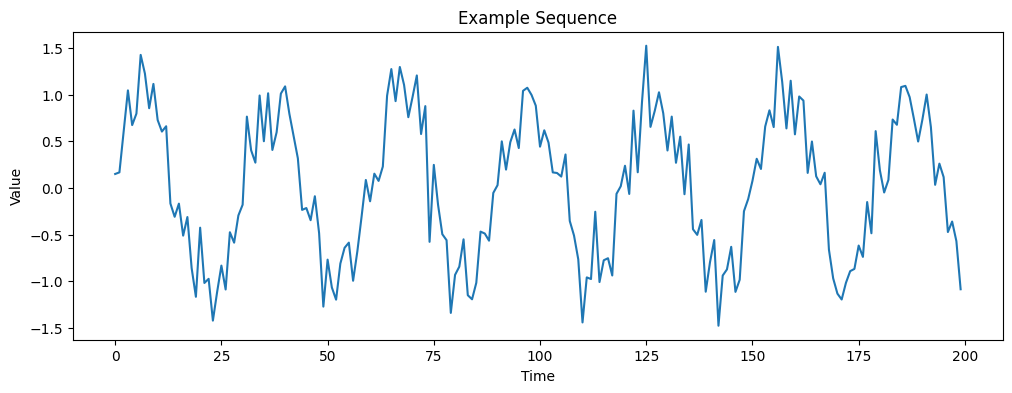

In [2]:
plt.figure(figsize=(12, 4))

plt.plot(df["time"], df["value"])

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Example Sequence")

plt.show()

## 8. Sequence Prediction Problems

Sequence problems can have different input-output structures.

### 8.1 Many-to-One

A complete sequence is used to predict one output.

$$
(x_1,x_2,\ldots,x_T)
\rightarrow y
$$

Example:

- Sentiment classification
- Sequence classification
- Predicting whether a machine will fail

---

### 8.2 One-to-Many

One input generates a sequence.

$$
x \rightarrow (y_1,y_2,\ldots,y_T)
$$

Example:

- Image caption generation

---

### 8.3 Many-to-Many

Each input corresponds to an output.

$$
(x_1,x_2,\ldots,x_T)
\rightarrow
(y_1,y_2,\ldots,y_T)
$$

Example:

- Part-of-speech tagging
- Named entity recognition

---

### 8.4 Sequence-to-Sequence

An input sequence is transformed into another sequence.

$$
(x_1,\ldots,x_T)
\rightarrow
(y_1,\ldots,y_{T'})
$$

where $T$ and $T'$ may be different.

Examples:

- Machine translation
- Text summarization
- Speech-to-text

## 9. Markov Assumption

A sequence may theoretically depend on its entire history:

$$
P(x_t\mid x_{t-1},x_{t-2},\ldots,x_1)
$$

A Markov model simplifies this by assuming that the future depends only on a limited amount of history.

For a first-order Markov model:

$$
P(x_t\mid x_{t-1},x_{t-2},\ldots)
=
P(x_t\mid x_{t-1})
$$

For a second-order model:

$$
P(x_t\mid x_{t-1},x_{t-2},\ldots)
=
P(x_t\mid x_{t-1},x_{t-2})
$$

The Markov assumption makes sequence modeling computationally easier.

However, real-world sequences may contain long-range dependencies that cannot be captured well using a small fixed-order Markov model.

## 10. Markov Chains

A Markov chain models transitions between states.

Suppose the system has states:

$$
S=\{s_1,s_2,\ldots,s_K\}
$$

The transition probability is:

$$
P_{ij}
=
P(X_t=s_j\mid X_{t-1}=s_i)
$$

All transition probabilities form a transition matrix:

$$
P =
\begin{bmatrix}
P_{11} & P_{12} & \cdots & P_{1K}\\
P_{21} & P_{22} & \cdots & P_{2K}\\
\vdots & \vdots & \ddots & \vdots\\
P_{K1} & P_{K2} & \cdots & P_{KK}
\end{bmatrix}
$$

Each row must satisfy:

$$
\sum_j P_{ij}=1
$$

Markov chains are useful when the sequence can be naturally represented using a finite set of states.

## 11. Hidden Markov Models

In a Hidden Markov Model (HMM), the underlying state is not directly observed.

Instead, we observe emissions generated by hidden states.

Let:

$$
Z_t
$$

be the hidden state and:

$$
X_t
$$

be the observed value.

The model assumes:

$$
P(Z_t\mid Z_{t-1},Z_{t-2},\ldots)
=
P(Z_t\mid Z_{t-1})
$$

and:

$$
P(X_t\mid Z_t,Z_{t-1},\ldots)
=
P(X_t\mid Z_t)
$$

Therefore:

$$
Z_{t-1}\rightarrow Z_t\rightarrow Z_{t+1}
$$

and each hidden state generates an observation.

### Applications

- Speech recognition
- Biological sequence analysis
- Part-of-speech tagging
- Activity recognition
- Financial regime detection

HMMs are important classical sequence models and provide a foundation for understanding probabilistic sequence modeling.

## 12. Sliding Windows

A common technique for preparing sequence data is the **sliding window**.

Given:

$$
X=(x_1,x_2,\ldots,x_T)
$$

we select a window of length $L$:

$$
W_t=(x_t,x_{t+1},\ldots,x_{t+L-1})
$$

The next observation can be used as the target:

$$
y_t=x_{t+L}
$$

For example, with:

$$
L=3
$$

we obtain:

$$
(x_1,x_2,x_3)\rightarrow x_4
$$

$$
(x_2,x_3,x_4)\rightarrow x_5
$$

$$
(x_3,x_4,x_5)\rightarrow x_6
$$

and so on.

Sliding windows are fundamental when preparing sequential data for machine-learning models.

In [3]:
def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])

    return np.array(X), np.array(y)


values = df["value"].values

X_seq, y_seq = create_sequences(values, window_size=10)

print("X shape:", X_seq.shape)
print("y shape:", y_seq.shape)

X shape: (190, 10)
y shape: (190,)


## 13. Splitting Sequential Data

Randomly shuffling sequential data before splitting can cause **temporal leakage**.

For ordinary i.i.d. data, we often use:

$$
\text{Random Split}
$$

For sequential data, we usually preserve temporal ordering.

For example:

$$
\underbrace{x_1,\ldots,x_T}_{Training}
\quad
\underbrace{x_{T+1},\ldots,x_V}_{Validation}
\quad
\underbrace{x_{V+1},\ldots,x_N}_{Test}
$$

The model should be trained using the past and evaluated on the future.

### Example

```text
Past ------------------------------> Future

|--------- Train ---------|---- Validation ----|---- Test ----|


---


## 14. Temporal Data Leakage

Temporal leakage occurs when information from the future is accidentally used to predict the past.

For example, suppose we want to predict:

$$
y_t
$$

but accidentally include:

$$
x_{t+1}
$$

as a feature.

The model now has access to information that would not be available at prediction time.

### Common sources

- Random train-test splitting
- Future values used as features
- Scaling using the complete dataset
- Interpolation using future observations
- Feature engineering using future information
- Incorrect rolling statistics

### Important rule

> When predicting the future, every feature must be computable using information available at that prediction time.

## 15. Scaling Sequential Data

Scaling is often useful because sequence features can have very different magnitudes.

Common transformations include standardization:

$$
z_t=
\frac{x_t-\mu}{\sigma}
$$

and min-max scaling:

$$
x_t'=
\frac{x_t-x_{\min}}
{x_{\max}-x_{\min}}
$$

For time-series data, the scaler should be fitted using the **training data only**.

Correct:

$$
\mu,\sigma
\leftarrow
\text{Training Data}
$$

Then apply the same transformation to validation and test data.

Incorrect:

$$
\mu,\sigma
\leftarrow
\text{Entire Dataset}
$$

because this can introduce information from the future into the training process.

## 16. Baseline Models for Sequence Problems

Before using sophisticated sequence models, establish a simple baseline.

### 16.1 Persistence / Naive Forecast

Predict:

$$
\hat{x}_{t+1}=x_t
$$

This is surprisingly strong for some time-series problems.

### 16.2 Moving Average

Predict using recent observations:

$$
\hat{x}_{t+1}
=
\frac{1}{k}
\sum_{i=0}^{k-1}x_{t-i}
$$

### 16.3 Linear Regression with Lags

Use:

$$
[x_{t-1},x_{t-2},\ldots,x_{t-p}]
$$

as input features.

### 16.4 Tree-Based Models

Models such as Random Forest, XGBoost, and LightGBM can also be applied after constructing appropriate lagged and rolling features.

A sophisticated sequence model should outperform a meaningful baseline to justify its additional complexity.

## 17. Practical Example — Predicting the Next Value

We will create a synthetic sequence and use previous observations to predict the next observation.

The workflow is:

1. Generate sequence
2. Visualize sequence
3. Create sliding windows
4. Split chronologically
5. Train a baseline model
6. Evaluate predictions

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

X_seq, y_seq = create_sequences(values, window_size=10)

split = int(len(X_seq) * 0.8)

X_train = X_seq[:split]
X_test = X_seq[split:]

y_train = y_seq[:split]
y_test = y_seq[split:]

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.31618220703906186
MAE: 0.28469501274395537


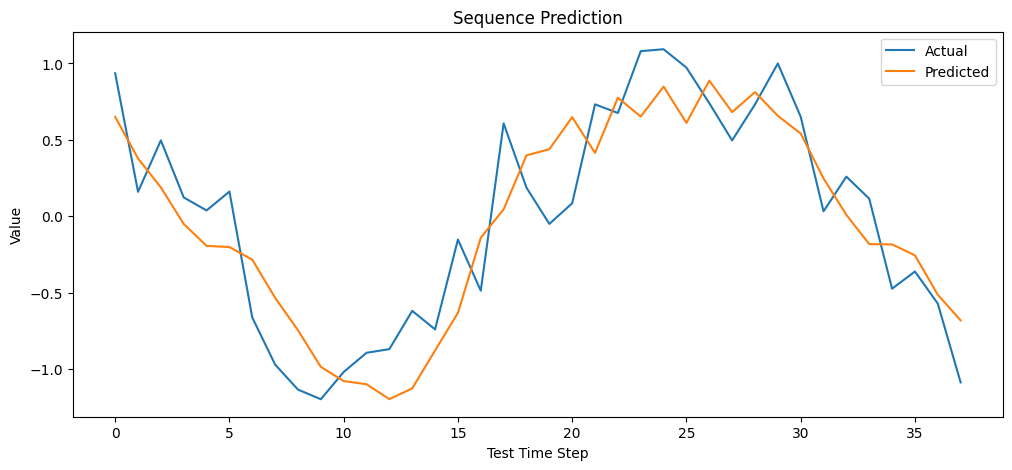

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(y_test, label="Actual")
plt.plot(predictions, label="Predicted")

plt.xlabel("Test Time Step")
plt.ylabel("Value")
plt.title("Sequence Prediction")

plt.legend()
plt.show()

## 18. Important Concepts

### 18.1 Short-Term Dependencies

The current value depends primarily on recent observations.

Example:

$$
x_t\approx f(x_{t-1},x_{t-2})
$$

---

### 18.2 Long-Term Dependencies

The current value may depend on observations far in the past.

$$
x_t\approx f(x_{t-1},x_{t-2},\ldots,x_{t-100})
$$

Capturing long-term dependencies is difficult for some classical models and motivated the development of advanced neural sequence architectures.

---

### 18.3 Seasonality

A pattern repeats at a particular period.

For example:

$$
x_t\approx x_{t-s}
$$

where $s$ is the seasonal period.

---

### 18.4 Trend

A systematic long-term increase or decrease.

---

### 18.5 Noise

Random variation that cannot be reliably predicted.

A useful conceptual decomposition is:

$$
X_t = Trend_t + Seasonality_t + Noise_t
$$

## 19. Challenges in Sequence Modeling

Sequence problems introduce several challenges.

### 1. Variable Sequence Length

Different examples may contain different numbers of observations.

### 2. Long-Term Dependencies

Important information may occur far back in the sequence.

### 3. Missing Observations

Real-world sequences frequently contain missing values.

### 4. Irregular Sampling

Observations may not occur at equally spaced time intervals.

### 5. Non-Stationarity

The statistical properties of the sequence may change over time.

### 6. Noise

Measurements may contain substantial random variation.

### 7. Temporal Leakage

Future information can accidentally enter the training process.

### 8. Distribution Shift

The future distribution may differ from the training distribution.

### 9. Computational Cost

Long sequences can require substantial memory and computation.

### 10. Evaluation Complexity

A random train-test split may not represent the actual deployment scenario.

## 20. Advantages and Disadvantages of Sequence Modeling

### Advantages

- Preserves ordering information
- Captures temporal dependencies
- Can model sequential patterns
- Useful for forecasting
- Applicable to text, speech, sensors, and events
- Can model complex temporal relationships

### Disadvantages

- More difficult than ordinary tabular modeling
- Temporal leakage is easy to introduce
- Long sequences can be computationally expensive
- Missing and irregular observations require special handling
- Model evaluation can be more complicated
- Distribution changes can reduce performance

## 21. Classical vs Deep Sequence Models

Sequence modeling has evolved from probabilistic and statistical approaches to neural architectures.

| Approach | Main Idea |
|---|---|
| Markov Chain | Model transitions between states |
| Hidden Markov Model | Model hidden states and observations |
| Autoregressive Model | Predict using previous observations |
| Lagged Regression | Convert sequence into supervised features |
| RNN | Maintain a learned hidden state |
| LSTM | Handle longer dependencies using gated memory |
| GRU | Simplified gated recurrent architecture |
| Transformer | Use attention to model relationships between sequence elements |

Classical models remain useful because they are often:

- Easier to interpret
- Faster to train
- Strong baselines
- Effective with limited data

Deep sequence models become particularly useful when:

- The sequence structure is complex
- Large datasets are available
- Long-range dependencies matter
- Representation learning is important

## 22. When to Use Sequence Modeling

Sequence modeling is appropriate when the **ordering of observations carries predictive information**.

Ask:

1. Does the order of observations matter?
2. Does the past influence the future?
3. Are there temporal or sequential patterns?
4. Are observations dependent?
5. Would shuffling the observations destroy useful information?

If the answer is yes, a sequence-based approach may be appropriate.

### Examples

| Problem | Sequence Modeling? |
|---|---|
| House price from static features | Usually no |
| Stock forecasting | Yes |
| Weather forecasting | Yes |
| Text classification | Yes |
| Customer purchase history | Yes |
| Image classification | Usually no |
| Sensor monitoring | Yes |
| Random tabular classification | Usually no |

## 23. Sequence Modeling Workflow

A practical sequence-learning workflow is:

$$
\boxed{
\text{Understand Sequence}
\rightarrow
\text{Clean Data}
\rightarrow
\text{Create Features}
\rightarrow
\text{Temporal Split}
\rightarrow
\text{Baseline}
\rightarrow
\text{Model}
\rightarrow
\text{Evaluate}
}
$$

### Step 1 — Understand the sequence

Identify:

- Ordering
- Sampling frequency
- Dependencies
- Sequence length
- Missing values

### Step 2 — Prepare the data

Handle:

- Missing values
- Scaling
- Outliers
- Irregular timestamps

### Step 3 — Create representations

Possible approaches:

- Lag features
- Rolling statistics
- Sliding windows
- State representations
- Learned representations

### Step 4 — Split chronologically

Avoid future information entering the training set.

### Step 5 — Establish a baseline

Always compare against a simple model.

### Step 6 — Train a sequence model

Choose an appropriate classical or deep architecture.

### Step 7 — Evaluate using realistic future-like data

The evaluation process should mimic deployment.

## 24. Key Takeaways

- Sequence data contains an important ordering structure.
- Observations in a sequence may not be independent.
- Temporal dependence is a central concept in sequence modeling.
- Lagged features convert sequence prediction into supervised learning.
- Autocorrelation measures dependence between observations separated by a lag.
- Markov models use assumptions about limited historical dependence.
- Hidden Markov Models introduce latent states.
- Sliding windows are widely used to construct training examples.
- Sequential data should generally be split chronologically.
- Temporal leakage must be avoided.
- Scaling should be fitted using training data only.
- Simple baselines should be established before complex models.
- Classical models and deep learning models are complementary.
- RNNs, LSTMs, GRUs, and Transformers will be studied more deeply in the Deep Learning section.

# Final Perspective

Sequence data introduces an important change in the way we think about machine learning.

For ordinary tabular learning, we often ask:

$$
y=f(x)
$$

For sequential learning, we instead ask:

$$
y_t=f(x_t,x_{t-1},x_{t-2},\ldots)
$$

The model must therefore understand not only **what information exists**, but also **when that information occurred and how previous observations influence future observations**.

This idea forms the foundation for:

- Time-series forecasting
- Sequential classification
- Speech recognition
- Natural language processing
- Event prediction
- Sensor modeling
- Recurrent neural networks
- Attention mechanisms
- Transformers

The next step is to learn increasingly powerful methods for representing and learning from these dependencies.